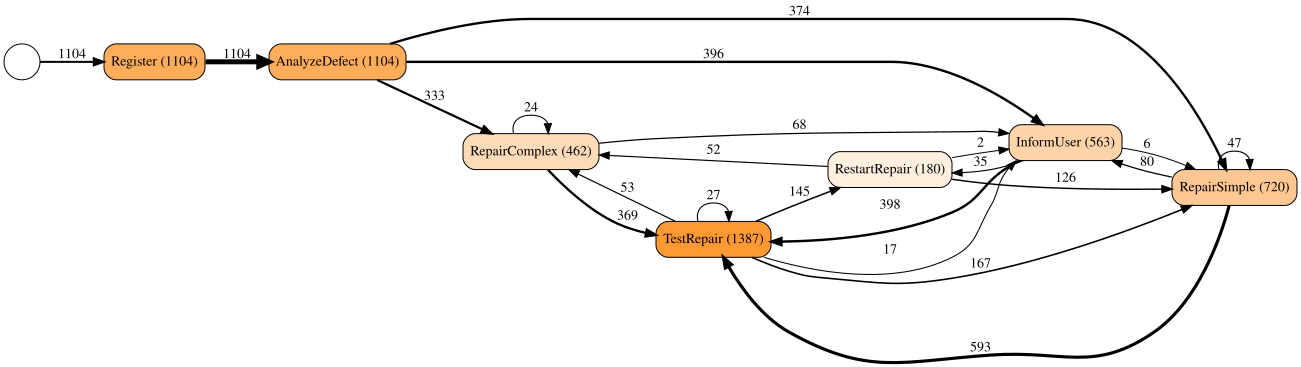

In [8]:
import graphviz
from IPython.display import display

MIN_NODE_FREQ = 2
MIN_EDGE_FREQ = 2

G_filtered = graphviz.Digraph()
G_filtered.graph_attr['rankdir'] = 'LR'
G_filtered.node_attr['shape'] = 'Mrecord'

valid_nodes = set()

for event in w_net:
    value = ev_counter.get(event, 0)

    if value >= MIN_NODE_FREQ:
        valid_nodes.add(event)

        if color_max != color_min:
            alpha = int(40 + (value - color_min) / (color_max - color_min) * 215)
        else:
            alpha = 255
        my_color = f"#ff9933{alpha:02x}"
        text = f"{event} ({value})"

        G_filtered.node(event, label=text, style="rounded,filled", fillcolor=my_color)

G_filtered.node("start", shape="circle", label="", style="filled", fillcolor="white")
for ev_start in ev_start_set:
    if ev_start in valid_nodes:
        start_freq = ev_counter[ev_start]
        if start_freq >= MIN_EDGE_FREQ:
            G_filtered.edge("start", ev_start, label=str(start_freq), penwidth="2")

for ev_end in ev_end_set:
    if ev_end in valid_nodes:
        G_filtered.node(ev_end, shape="circle", label="")

for edge, edge_freq in edge_counter.items():
    ev_i, ev_j = edge

    if ev_i in valid_nodes and ev_j in valid_nodes and edge_freq >= MIN_EDGE_FREQ:

        if edge_max != edge_min:
            thickness = 1 + 4 * ((edge_freq - edge_min) / (edge_max - edge_min))
        else:
            thickness = 2.0

        G_filtered.edge(ev_i, ev_j, label=str(edge_freq), penwidth=str(round(thickness, 2)))

display(G_filtered)

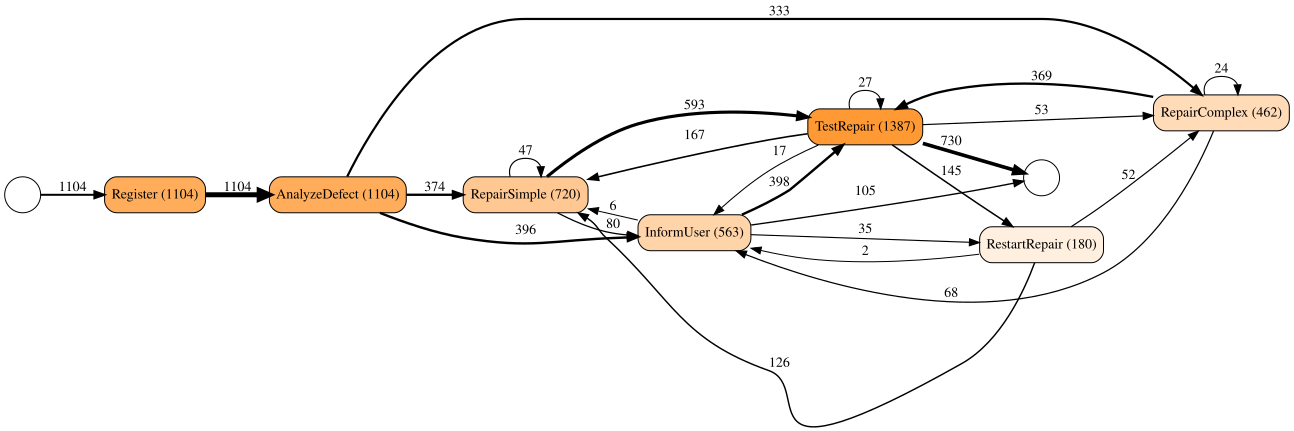

In [6]:
import graphviz
from IPython.display import display
from functools import reduce

ev_counter = dict()
for w_trace in workflow_log:
    for ev in w_trace:
        ev_counter[ev] = ev_counter.get(ev, 0) + 1

color_min = min(ev_counter.values())
color_max = max(ev_counter.values())

edge_counter = dict()
for w_trace in workflow_log:
    for i in range(0, len(w_trace)-1):
        ev_i = w_trace[i]
        ev_j = w_trace[i+1]
        edge = (ev_i, ev_j)
        edge_counter[edge] = edge_counter.get(edge, 0) + 1

edge_min = min(edge_counter.values())
edge_max = max(edge_counter.values())

ev_source = set(w_net.keys())
ev_target = reduce(lambda x,y: x|y, w_net.values())
ev_start_set = ev_source - ev_target
ev_end_set = ev_target - ev_source

G = graphviz.Digraph()
G.graph_attr['rankdir'] = 'LR'
G.node_attr['shape'] = 'Mrecord'

for event in w_net:
    value = ev_counter[event]
    if color_max != color_min:
        alpha = int(40 + (value - color_min) / (color_max - color_min) * 215)
    else:
        alpha = 255
    my_color = f"#ff9933{alpha:02x}"
    text = f"{event} ({value})"
    G.node(event, label=text, style="rounded,filled", fillcolor=my_color)

    for following_event in w_net[event]:
        edge = (event, following_event)
        edge_freq = edge_counter.get(edge, 0)

        if edge_max != edge_min:
            thickness = 1 + 4 * ((edge_freq - edge_min) / (edge_max - edge_min))
        else:
            thickness = 2.0

        G.edge(event, following_event, label=str(edge_freq), penwidth=str(round(thickness, 2)))

G.node("start", shape="circle", label="", style="filled", fillcolor="white")
for ev_start in ev_start_set:
    start_freq = ev_counter[ev_start]
    G.edge("start", ev_start, label=str(start_freq), penwidth="2")

for ev_end in ev_end_set:
    G.node(ev_end, shape="circle", label="")

display(G)

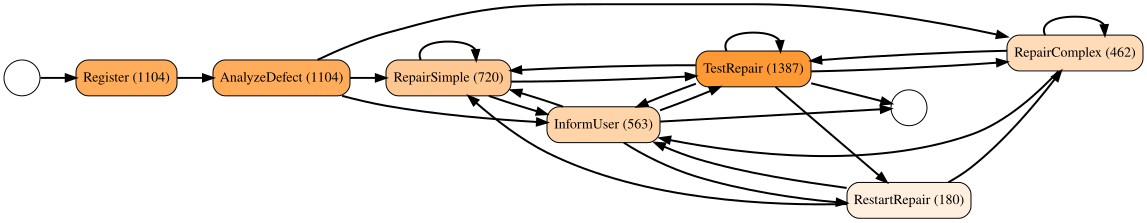

In [5]:
import graphviz
from IPython.display import display
from functools import reduce

ev_counter = dict()
for w_trace in workflow_log:
    for ev in w_trace:
        ev_counter[ev] = ev_counter.get(ev, 0) + 1

color_min = min(ev_counter.values())
color_max = max(ev_counter.values())

ev_source = set(w_net.keys())
ev_target = reduce(lambda x,y: x|y, w_net.values())

ev_start_set = ev_source - ev_target
ev_end_set = ev_target - ev_source

G = graphviz.Digraph()
G.graph_attr['rankdir'] = 'LR'
G.node_attr['shape'] = 'Mrecord'
G.edge_attr.update(penwidth='2')

for event in w_net:
    value = ev_counter[event]

    if color_max != color_min:
        alpha = int(40 + (value - color_min) / (color_max - color_min) * 215)
    else:
        alpha = 255

    my_color = f"#ff9933{alpha:02x}"

    text = f"{event} ({value})"

    G.node(event, label=text, style="rounded,filled", fillcolor=my_color)

    for following_event in w_net[event]:
        G.edge(event, following_event)

G.node("start", shape="circle", label="", style="filled", fillcolor="white")
for ev_start in ev_start_set:
    G.edge("start", ev_start)

for ev_end in ev_end_set:
    G.node(ev_end, shape="circle", label="")

display(G)

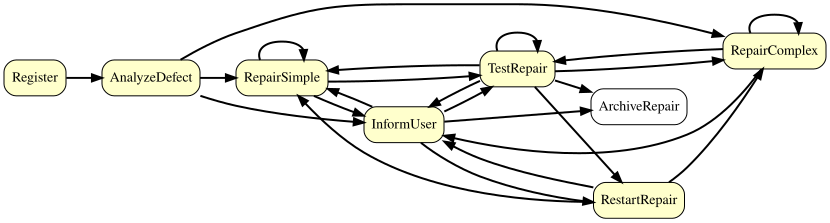

In [4]:
import graphviz
from IPython.display import display

G = graphviz.Digraph()

for event in w_net:
    G.node(event, style="rounded,filled", fillcolor="#ffffcc")

    for following_event in w_net[event]:
        G.edge(event, following_event)

G.graph_attr['rankdir'] = 'LR'
G.node_attr['shape'] = 'Mrecord'
G.edge_attr.update(penwidth='2')

display(G)

In [3]:
workflow_log = []
for trace in log:
    workflow_trace = []
    for event in trace[0::2]:
        # get the event name from the event in the log
        event_name = event.get_attributes()['concept:name'].get_value()
        workflow_trace.append(event_name)
    workflow_log.append(workflow_trace)

w_net = dict()
for w_trace in workflow_log:
    for i in range(0, len(w_trace)-1):
        ev_i, ev_j = w_trace[i], w_trace[i+1]
        if ev_i not in w_net.keys():
            w_net[ev_i] = set()
        w_net[ev_i].add(ev_j)

print(w_net)

{'Register': {'AnalyzeDefect'}, 'AnalyzeDefect': {'RepairSimple', 'RepairComplex', 'InformUser'}, 'RepairComplex': {'TestRepair', 'RepairComplex', 'InformUser'}, 'TestRepair': {'TestRepair', 'RestartRepair', 'InformUser', 'ArchiveRepair', 'RepairSimple', 'RepairComplex'}, 'RepairSimple': {'TestRepair', 'RepairSimple', 'InformUser'}, 'InformUser': {'TestRepair', 'RestartRepair', 'RepairSimple', 'ArchiveRepair'}, 'RestartRepair': {'RepairSimple', 'RepairComplex', 'InformUser'}}


In [2]:
from opyenxes.data_in.XUniversalParser import XUniversalParser
path = 'repairExample.xes'
with open(path) as log_file:
    # parse the log
    log = XUniversalParser().parse(log_file)[0]

In [1]:
!pip install opyenxes graphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for opyenxes: filename=opyenxes-0.3.0-py2.py3-none-any.whl size=79209 sha256=b19c30d623896263ada85c9e4ffeb1ed7482456e1bd88a0b10504bf359101568
  Stored in directory: /root/.cache/pip/wheels/b1/2e/a7/23daa683a0f8015227c3dfd20f06ef495994704c92802beed8
Successfully built opyenxes
